# Historical Vegetation Outage Analysis Validation

## Objective

Reconstruct the 2023–2024 historical outage analysis using data available
through the end of 2024.

The purpose of this notebook is to establish a reproducible historical
baseline that can later be evaluated against 2025–2026 outage data.

Development is performed using synthetic data calibrated to aggregate
characteristics of the original 2023–2024 datasets. Individual records,
substation identifiers, and feeder identifiers are fictional.

No 2025 or 2026 information is used in constructing the historical baseline.

In [46]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import sys
import sklearn

print(sys.executable)
print(sys.version)
print(sklearn.__version__)

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

print("Vegetation ML environment ready.")


c:\Users\physi\anaconda3\envs\vegetation-ml\python.exe
3.12.15 | packaged by Anaconda, Inc. | (main, Oct  1 2026, 20:14:50) [MSC v.1942 64 bit (AMD64)]
1.9.1
Vegetation ML environment ready.


In [47]:
PROJECT_ROOT = Path.cwd().parent

DATA_DIR = PROJECT_ROOT / "data" / "synthetic"
OUTPUT_DIR = PROJECT_ROOT / "outputs"

DATA_2023 = DATA_DIR / "2023_synthetic_outages.csv"
DATA_2024 = DATA_DIR / "2024_synthetic_outages.csv"

print("Project root:", PROJECT_ROOT)
print("2023 data:", DATA_2023)
print("2024 data:", DATA_2024)

Project root: c:\Portfolio\Vegetation\vegetation-validation
2023 data: c:\Portfolio\Vegetation\vegetation-validation\data\synthetic\2023_synthetic_outages.csv
2024 data: c:\Portfolio\Vegetation\vegetation-validation\data\synthetic\2024_synthetic_outages.csv


In [48]:
assert DATA_2023.exists(), f"File not found: {DATA_2023}"
assert DATA_2024.exists(), f"File not found: {DATA_2024}"

print("Both historical data files found.")

Both historical data files found.


In [49]:
outages_2023 = pd.read_csv(DATA_2023)
outages_2024 = pd.read_csv(DATA_2024)

print(f"2023: {len(outages_2023):,} rows")
print(f"2024: {len(outages_2024):,} rows")

2023: 350 rows
2024: 479 rows


In [50]:
display(outages_2023.head())
display(outages_2024.head())

,Year,Month,Substation_ID,Feeder_ID,Duration_Minutes,Customers_Out,Customer_Minutes,Event_Type,Temperature_C,Precipitation_mm,Wind_Speed_kmh
0,2023,6,1,1,48.20,1,48,Meter,28.3,0.0,3.9
1,2023,9,4,1,67.43,2,135,Line Section,9.1,37.7,16.4
2,2023,10,9,3,292.60,26,7608,Line Section,12.7,0.0,28.8
3,2023,6,23,2,237.13,1,237,Meter,16.2,8.8,17.6
4,2023,8,13,1,1180.92,1,1181,Meter,25.7,0.0,17.1


,Year,Month,Substation_ID,Feeder_ID,Duration_Minutes,Customers_Out,Customer_Minutes,Event_Type,Temperature_C,Precipitation_mm,Wind_Speed_kmh
0,2024,7,17,3,162.50,30,4875,Line Section,18.0,0.1,2.8
1,2024,6,21,1,80.10,35,2804,Line Section,22.4,0.0,12.7
2,2024,6,3,3,376.81,24,9043,Line Section,22.3,0.0,18.6
3,2024,7,10,3,161.80,1,162,Transformer,26.1,0.0,12.1
4,2024,11,10,1,0.00,0,0,No Outage,9.3,0.0,55.8


In [51]:
print("2023 shape:", outages_2023.shape)
print("2024 shape:", outages_2024.shape)

print("\n2023 columns:")
print(outages_2023.columns.tolist())

print("\n2024 columns:")
print(outages_2024.columns.tolist())

2023 shape: (350, 11)
2024 shape: (479, 11)

2023 columns:
['Year', 'Month', 'Substation_ID', 'Feeder_ID', 'Duration_Minutes', 'Customers_Out', 'Customer_Minutes', 'Event_Type', 'Temperature_C', 'Precipitation_mm', 'Wind_Speed_kmh']

2024 columns:
['Year', 'Month', 'Substation_ID', 'Feeder_ID', 'Duration_Minutes', 'Customers_Out', 'Customer_Minutes', 'Event_Type', 'Temperature_C', 'Precipitation_mm', 'Wind_Speed_kmh']


## 1. Data Integrity Validation

Before reproducing the historical analysis, validate that the two annual
datasets conform to the expected schema and basic data-quality requirements.

These checks are intended to fail early if future input data do not satisfy
the assumptions used by the analysis.

In [52]:
EXPECTED_COLUMNS = {
    "Year",
    "Month",
    "Substation_ID",
    "Feeder_ID",
    "Duration_Minutes",
    "Customers_Out",
    "Customer_Minutes",
    "Event_Type",
    "Temperature_C",
    "Precipitation_mm",
    "Wind_Speed_kmh",
}

def validate_schema(df, name):
    missing = EXPECTED_COLUMNS - set(df.columns)
    unexpected = set(df.columns) - EXPECTED_COLUMNS

    assert not missing, f"{name}: missing columns: {missing}"
    assert not unexpected, f"{name}: unexpected columns: {unexpected}"

    print(f"{name}: schema valid")


validate_schema(outages_2023, "2023")
validate_schema(outages_2024, "2024")

2023: schema valid
2024: schema valid


In [53]:
assert outages_2023["Year"].eq(2023).all(), \
    "2023 dataset contains records from another year"

assert outages_2024["Year"].eq(2024).all(), \
    "2024 dataset contains records from another year"

print("Year validation passed.")

Year validation passed.


In [54]:
for name, df in [("2023", outages_2023), ("2024", outages_2024)]:
    print(f"\n{name}")
    print("-" * 30)
    print(f"Rows: {len(df):,}")
    print(f"Duplicate rows: {df.duplicated().sum()}")
    print(f"Missing values: {df.isna().sum().sum()}")


2023
------------------------------
Rows: 350
Duplicate rows: 0
Missing values: 0

2024
------------------------------
Rows: 479
Duplicate rows: 0
Missing values: 0


In [55]:
assert outages_2023["Month"].between(1, 12).all()
assert outages_2024["Month"].between(1, 12).all()

for name, df in [("2023", outages_2023), ("2024", outages_2024)]:

    assert (df["Duration_Minutes"] >= 0).all(), \
        f"{name}: negative outage duration found"

    assert (df["Customers_Out"] >= 0).all(), \
        f"{name}: negative customer count found"

    assert (df["Customer_Minutes"] >= 0).all(), \
        f"{name}: negative customer-minutes found"

    assert (df["Precipitation_mm"] >= 0).all(), \
        f"{name}: negative precipitation found"

print("Range validation passed.")

Range validation passed.


In [56]:
for name, df in [("2023", outages_2023), ("2024", outages_2024)]:

    expected_customer_minutes = (
        df["Duration_Minutes"] * df["Customers_Out"]
    ).round().astype(int)

    assert (
        df["Customer_Minutes"] == expected_customer_minutes
    ).all(), f"{name}: Customer_Minutes calculation mismatch"

print("Customer-minute validation passed.")

Customer-minute validation passed.


In [57]:
historical = pd.concat(
    [outages_2023, outages_2024],
    ignore_index=True
)

print(f"Combined historical records: {len(historical):,}")
print(historical["Year"].value_counts().sort_index())

Combined historical records: 829
Year
2023    350
2024    479
Name: count, dtype: int64


In [58]:
historical.info()

<class 'pandas.DataFrame'>
RangeIndex: 829 entries, 0 to 828
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Year              829 non-null    int64  
 1   Month             829 non-null    int64  
 2   Substation_ID     829 non-null    int64  
 3   Feeder_ID         829 non-null    int64  
 4   Duration_Minutes  829 non-null    float64
 5   Customers_Out     829 non-null    int64  
 6   Customer_Minutes  829 non-null    int64  
 7   Event_Type        829 non-null    str    
 8   Temperature_C     829 non-null    float64
 9   Precipitation_mm  829 non-null    float64
 10  Wind_Speed_kmh    829 non-null    float64
dtypes: float64(4), int64(6), str(1)
memory usage: 71.4 KB


## 2. Historical Baseline

The original vegetation-outage analysis examined whether outage severity
patterns differed across substations and feeders.

Before reproducing the clustering analysis, establish descriptive statistics
for the combined 2023–2024 dataset and construct a stable feeder identifier.

The clustering stage will initially use the same two primary severity
measures used in the refined historical analysis:

- outage duration
- customers affected

In [59]:
historical["Substation_Feeder"] = (
    "SUB"
    + historical["Substation_ID"].astype(str).str.zfill(2)
    + "_FDR"
    + historical["Feeder_ID"].astype(str).str.zfill(2)
)

historical[
    ["Substation_ID", "Feeder_ID", "Substation_Feeder"]
].head()

,Substation_ID,Feeder_ID,Substation_Feeder
0,1,1,SUB01_FDR01
1,4,1,SUB04_FDR01
2,9,3,SUB09_FDR03
3,23,2,SUB23_FDR02
4,13,1,SUB13_FDR01


In [60]:
print(
    "Unique substations:",
    historical["Substation_ID"].nunique()
)

print(
    "Unique feeder combinations:",
    historical["Substation_Feeder"].nunique()
)

Unique substations: 24
Unique feeder combinations: 72


In [61]:
historical[
    [
        "Duration_Minutes",
        "Customers_Out",
        "Customer_Minutes",
        "Temperature_C",
        "Precipitation_mm",
        "Wind_Speed_kmh",
    ]
].describe().round(2)

,Duration_Minutes,Customers_Out,Customer_Minutes,Temperature_C,Precipitation_mm,Wind_Speed_kmh
count,829.00,829.00,829.00,829.00,829.00,829.00
mean,200.28,22.76,4573.85,21.38,0.90,15.95
std,263.46,52.71,12028.96,7.91,2.69,9.88
min,0.00,0.00,0.00,-9.60,0.00,0.00
25%,56.21,1.00,158.00,19.30,0.00,9.10
50%,121.50,6.00,768.00,23.00,0.00,14.20
75%,239.67,22.00,3588.00,26.60,0.60,21.10
max,2400.00,627.00,114213.00,36.60,37.70,55.80


In [62]:
event_summary = (
    historical["Event_Type"]
    .value_counts()
    .rename_axis("Event_Type")
    .reset_index(name="Count")
)

event_summary["Percent"] = (
    100 * event_summary["Count"] / len(historical)
).round(1)

event_summary

,Event_Type,Count,Percent
0,Line Section,546,65.9
1,Meter,144,17.4
2,Transformer,101,12.2
3,No Outage,22,2.7
4,Feeder,15,1.8
5,Substation,1,0.1


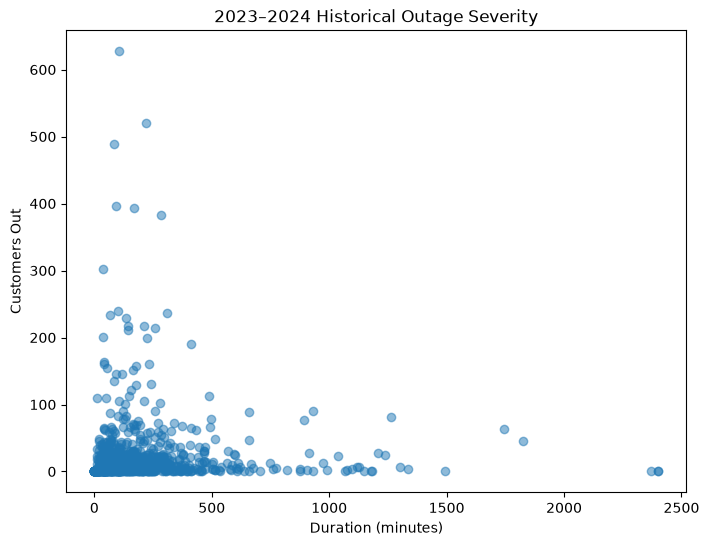

In [63]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(
    historical["Duration_Minutes"],
    historical["Customers_Out"],
    alpha=0.5
)

ax.set_xlabel("Duration (minutes)")
ax.set_ylabel("Customers Out")
ax.set_title("2023–2024 Historical Outage Severity")

plt.show()

### Initial Observation

The two severity variables are strongly right-skewed. Most outage events are
concentrated at relatively low duration and customer counts, with a small
number of extreme events.

The scatterplot also suggests different forms of outage severity. Some events
affect relatively large numbers of customers for shorter periods, while
others have long durations but affect relatively few customers.

Because the purpose of this stage is to reproduce the historical analytical
baseline, the original feature treatment will initially be retained.
Alternative transformations and modeling choices will be evaluated
separately rather than introduced retrospectively.

In [64]:
severity_features = historical[
    ["Duration_Minutes", "Customers_Out"]
]

severity_features.agg(
    ["mean", "median", "std", "skew", "min", "max"]
).round(2)


,Duration_Minutes,Customers_Out
mean,200.28,22.76
median,121.50,6.00
std,263.46,52.71
skew,3.96,6.03
min,0.00,0.00
max,2400.00,627.00


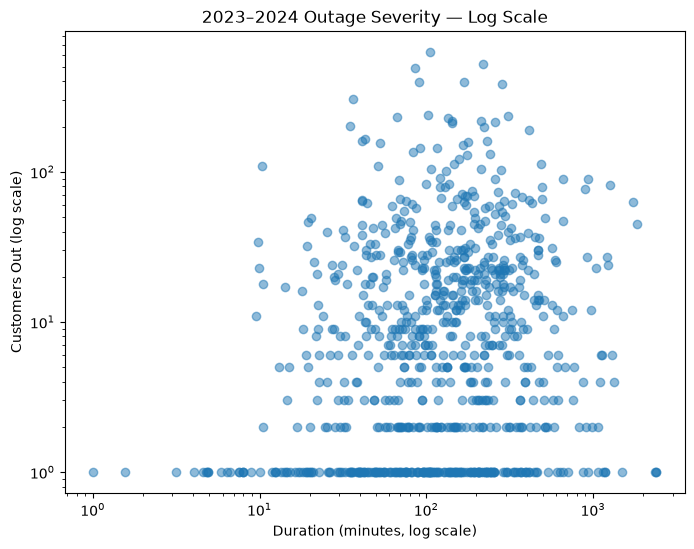

In [65]:
fig, ax = plt.subplots(figsize=(8, 6))

outage_events = historical[
    (historical["Duration_Minutes"] > 0) &
    (historical["Customers_Out"] > 0)
]

ax.scatter(
    outage_events["Duration_Minutes"],
    outage_events["Customers_Out"],
    alpha=0.5
)

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel("Duration (minutes, log scale)")
ax.set_ylabel("Customers Out (log scale)")
ax.set_title("2023–2024 Outage Severity — Log Scale")

plt.show()

## 3. Reproduction of Historical K-Means Baseline

The historical analysis used K-Means clustering to identify groups of outage
events based on two measures of outage severity:

- Duration_Minutes
- Customers_Out

To preserve the historical methodology, the raw features are standardized
using StandardScaler and K-Means is fitted with two clusters.

This section intentionally reproduces that methodology before considering
alternative transformations or clustering approaches.

In [68]:
cluster_data = historical[
    (historical["Duration_Minutes"] > 0) &
    (historical["Customers_Out"] > 0)
].copy()

print(f"All records: {len(historical):,}")
print(f"Outage records used for clustering: {len(cluster_data):,}")
print(f"Excluded zero-impact records: {len(historical) - len(cluster_data):,}")

All records: 829
Outage records used for clustering: 807
Excluded zero-impact records: 22


In [69]:
FEATURES = ["Duration_Minutes", "Customers_Out"]

X = cluster_data[FEATURES]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Verify standardization
pd.DataFrame(
    X_scaled,
    columns=FEATURES
).agg(["mean", "std"]).round(3)


,Duration_Minutes,Customers_Out
mean,0.000,0.000
std,1.001,1.001


In [70]:
kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

cluster_data["Cluster"] = kmeans.fit_predict(X_scaled)

cluster_summary = (
    cluster_data
    .groupby("Cluster")
    .agg(
        Events=("Cluster", "size"),
        Mean_Duration=("Duration_Minutes", "mean"),
        Median_Duration=("Duration_Minutes", "median"),
        Max_Duration=("Duration_Minutes", "max"),
        Mean_Customers_Out=("Customers_Out", "mean"),
        Median_Customers_Out=("Customers_Out", "median"),
        Max_Customers_Out=("Customers_Out", "max")
    )
    .round(2)
)

cluster_summary

c:\Users\physi\anaconda3\envs\vegetation-ml\Lib\site-packages\sklearn\cluster\_kmeans.py:1424: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


,Events,Mean_Duration,Median_Duration,Max_Duration,Mean_Customers_Out,Median_Customers_Out,Max_Customers_Out
Cluster,,,,,,,
0,781,207.53,125.69,2400.00,15.53,6.0,135
1,26,151.99,139.30,412.18,259.19,215.5,627


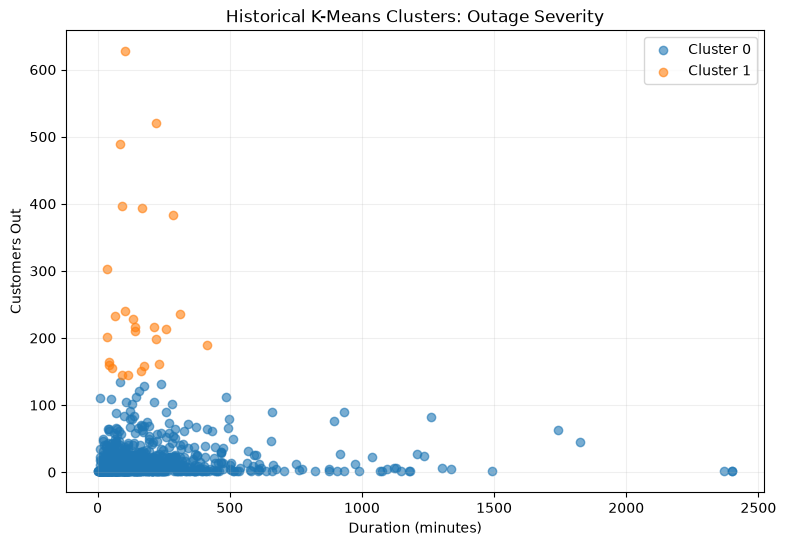

In [71]:
plt.figure(figsize=(9, 6))

for cluster in sorted(cluster_data["Cluster"].unique()):
    subset = cluster_data[cluster_data["Cluster"] == cluster]

    plt.scatter(
        subset["Duration_Minutes"],
        subset["Customers_Out"],
        alpha=0.6,
        label=f"Cluster {cluster}"
    )

plt.xlabel("Duration (minutes)")
plt.ylabel("Customers Out")
plt.title("Historical K-Means Clusters: Outage Severity")
plt.legend()
plt.grid(alpha=0.2)

plt.show()

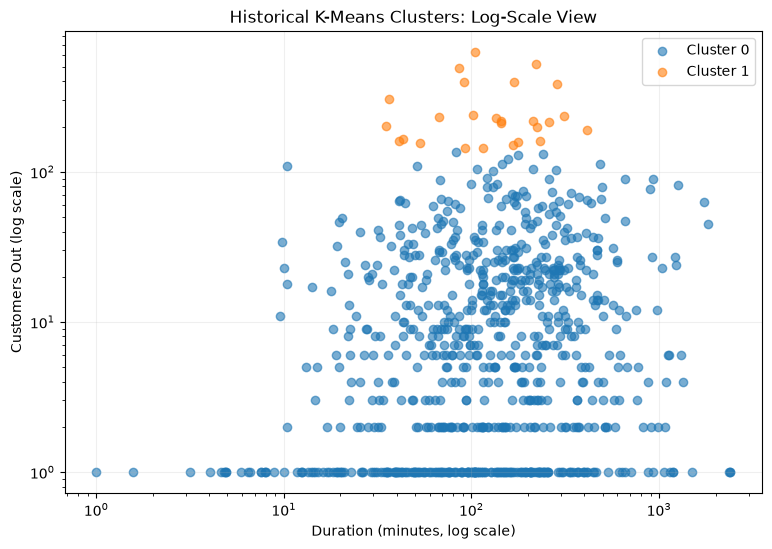

In [72]:
plt.figure(figsize=(9, 6))

for cluster in sorted(cluster_data["Cluster"].unique()):
    subset = cluster_data[cluster_data["Cluster"] == cluster]

    plt.scatter(
        subset["Duration_Minutes"],
        subset["Customers_Out"],
        alpha=0.6,
        label=f"Cluster {cluster}"
    )

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Duration (minutes, log scale)")
plt.ylabel("Customers Out (log scale)")
plt.title("Historical K-Means Clusters: Log-Scale View")
plt.legend()
plt.grid(alpha=0.2)

plt.show()

### Historical K-Means Baseline Results

The two-cluster K-Means model primarily separates a small group of
high-customer-impact outages from the remainder of the historical events.

Cluster 0 contains 781 of the 807 outage events and spans a broad range of
outage durations. Although these events generally affect fewer customers,
this cluster also contains the longest-duration outages in the dataset.

Cluster 1 contains only 26 events and is distinguished primarily by the
number of customers affected. The mean number of customers affected is
substantially higher than in Cluster 0, while the mean outage duration is
actually lower.

The log-scale visualization further shows that Cluster 0 contains substantial
internal structure that is compressed in the linear-scale visualization.
Long-duration, low-customer events and shorter-duration, moderate-customer
events remain grouped together.

Therefore, the clusters should not be interpreted simply as "low risk" and
"high risk." A more defensible interpretation is that the historical K-Means
model identifies a small high-customer-impact group while placing the much
broader range of remaining outage behavior into a single cluster.

This result reproduces the historical clustering methodology but also
highlights limitations of representing outage severity with two K-Means
clusters based solely on standardized duration and customer counts.

In [73]:
cluster_impact = (
    cluster_data
    .groupby("Cluster")
    .agg(
        Events=("Cluster", "size"),
        Mean_Customer_Minutes=("Customer_Minutes", "mean"),
        Median_Customer_Minutes=("Customer_Minutes", "median"),
        Total_Customer_Minutes=("Customer_Minutes", "sum")
    )
    .round(2)
)

cluster_impact["Percent_Total_Customer_Minutes"] = (
    100
    * cluster_impact["Total_Customer_Minutes"]
    / cluster_impact["Total_Customer_Minutes"].sum()
).round(1)

cluster_impact

,Events,Mean_Customer_Minutes,Median_Customer_Minutes,Total_Customer_Minutes,Percent_Total_Customer_Minutes
Cluster,,,,,
0,781,3544.96,759.0,2768613,73.0
1,26,39350.35,31083.5,1023109,27.0


### Customer Interruption Impact

Although Cluster 1 contains only 26 of the 807 outage events (3.2%), these
events account for 27.0% of total customer-minutes in the historical dataset.

The mean customer-minute impact per event is approximately eleven times
greater in Cluster 1 than in Cluster 0, indicating that the high-customer
cluster represents a small number of disproportionately consequential events.

However, Cluster 0 still accounts for 73.0% of total customer-minutes because
it contains the large majority of outage events and includes many
long-duration events.

This reinforces the conclusion that the two clusters represent different
forms of outage impact rather than a simple low-risk/high-risk division.

### Operational Interpretation **************

A small cluster of disproportionately high-impact events may provide a useful
starting point for operational prioritization. In a production utility
analysis, these events could be mapped to feeders or geographic locations to
determine whether customer interruption is concentrated in a relatively small
number of recurring areas.

If such concentration exists, those locations could be investigated as
potential candidates for targeted vegetation management or other reliability
interventions. Cluster membership itself does not establish vegetation risk
or causation; rather, it provides a data-driven method for identifying
high-impact events for further operational investigation.

## 4. Evaluation of the Historical Clustering Choice

The historical analysis used two K-Means clusters. Because K-Means requires
the number of clusters to be specified in advance, the two-cluster solution
is evaluated below rather than assumed to represent a natural division in
the outage data.

This evaluation does not alter the historical baseline. Its purpose is to
assess how strongly the data support the original modeling choice.

In [74]:
from sklearn.metrics import silhouette_score

silhouette_k2 = silhouette_score(
    X_scaled,
    cluster_data["Cluster"]
)

print(f"Silhouette score for k=2: {silhouette_k2:.3f}")

Silhouette score for k=2: 0.769


In [75]:
silhouette_results = []

for k in range(2, 9):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = model.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    
    silhouette_results.append({
        "k": k,
        "Silhouette_Score": score
    })

silhouette_results = pd.DataFrame(silhouette_results)

silhouette_results


c:\Users\physi\anaconda3\envs\vegetation-ml\Lib\site-packages\sklearn\cluster\_kmeans.py:1424: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\physi\anaconda3\envs\vegetation-ml\Lib\site-packages\sklearn\cluster\_kmeans.py:1424: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\physi\anaconda3\envs\vegetation-ml\Lib\site-packages\sklearn\cluster\_kmeans.py:1424: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\physi\anaconda3\envs\vegetation-ml\Lib\site-packages\sklearn\cluster\_

,k,Silhouette_Score
0,2,0.769253
1,3,0.752877
2,4,0.521208
3,5,0.541516
4,6,0.527840
5,7,0.537871
6,8,0.473592


#### Let's try k=3 since the silhouette score was close to k=2

In [76]:
kmeans_3 = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

cluster_data["Cluster_k3"] = kmeans_3.fit_predict(X_scaled)

cluster_summary_k3 = (
    cluster_data
    .groupby("Cluster_k3")
    .agg(
        Events=("Cluster_k3", "size"),
        Mean_Duration=("Duration_Minutes", "mean"),
        Median_Duration=("Duration_Minutes", "median"),
        Mean_Customers_Out=("Customers_Out", "mean"),
        Median_Customers_Out=("Customers_Out", "median"),
        Total_Customer_Minutes=("Customer_Minutes", "sum")
    )
    .round(2)
)

cluster_summary_k3

c:\Users\physi\anaconda3\envs\vegetation-ml\Lib\site-packages\sklearn\cluster\_kmeans.py:1424: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


,Events,Mean_Duration,Median_Duration,Mean_Customers_Out,Median_Customers_Out,Total_Customer_Minutes
Cluster_k3,,,,,,
0,741,159.21,115.71,15.25,6.0,2012897
1,39,1128.76,1036.47,17.74,4.0,744508
2,27,149.43,135.70,254.59,214.0,1034317


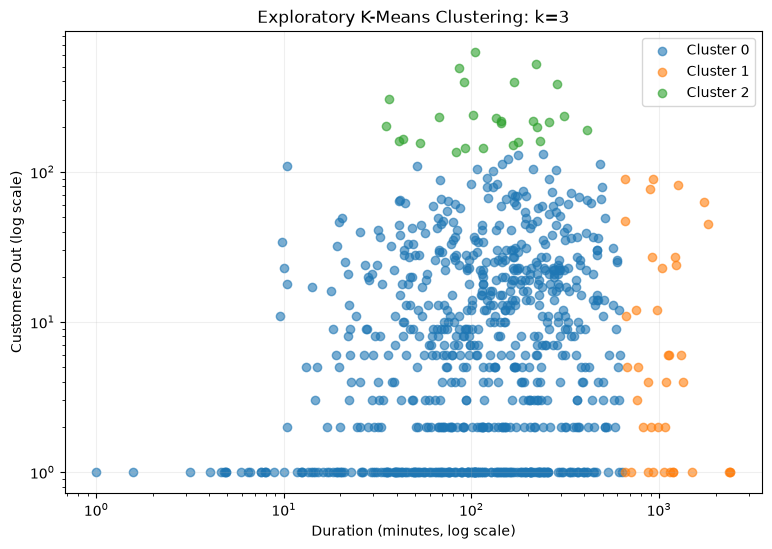

In [77]:
plt.figure(figsize=(9, 6))

for cluster in sorted(cluster_data["Cluster_k3"].unique()):
    subset = cluster_data[
        cluster_data["Cluster_k3"] == cluster
    ]

    plt.scatter(
        subset["Duration_Minutes"],
        subset["Customers_Out"],
        alpha=0.6,
        label=f"Cluster {cluster}"
    )

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Duration (minutes, log scale)")
plt.ylabel("Customers Out (log scale)")
plt.title("Exploratory K-Means Clustering: k=3")
plt.legend()
plt.grid(alpha=0.2)

plt.show()

### Evaluation of Cluster Count

The original two-cluster solution produced the highest silhouette score among
the values tested (0.769 for k=2). A three-cluster solution produced a
slightly lower but comparable score of 0.753.

Inspection of the three-cluster solution reveals additional operationally
meaningful structure. Rather than separating only a small group of
high-customer-impact events, the three-cluster model distinguishes:

- a broad group of typical outage events,
- a small group characterized by unusually long outage duration, and
- a small group characterized by unusually large numbers of customers affected.

The long-duration and high-customer clusters represent different dimensions
of outage severity. This distinction is obscured in the two-cluster model,
where long-duration events remain grouped with the majority of outages.

Therefore, k=2 remains the reproduced historical baseline and provides the
strongest geometric separation according to silhouette score. However, the
k=3 exploratory result demonstrates that the mathematically strongest
clustering solution is not necessarily the most operationally informative.

For utility reliability analysis, the k=3 segmentation may provide more useful
starting points for investigating different intervention strategies. For
example, high-customer events may identify opportunities to reduce the number
of customers interrupted, while long-duration events may identify different
opportunities to reduce restoration time. Cluster membership alone does not
identify cause or establish that a particular intervention would improve
reliability.